## About {-}
ChatGPT translation of wavelet_cwt_tutorial.m, which is a basic wavelet tutorial.

### Background {-}
From Mathworks:
> The continuous wavelet transform (CWT) is a time-frequency transform, which is ideal for analyzing nonstationary signals. A signal being nonstationary means that its frequency-domain representation changes over time.

Link: https://www.mathworks.com/help/wavelet/ug/time-frequency-analysis-and-continuous-wavelet-transform.html

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ssqueezepy import cwt, wavs
from ssqueezepy.visuals import plot
from ssqueezepy.experimental import scale_to_freq

In [2]:
# -----------------------------
# Parameters and sample signals
# -----------------------------
t = np.linspace(0, 100, 5001)
dt = t[1] - t[0]

# MATLAB used sampfreq = 2*pi/dt
# ssqueezepy wants sampling period dt directly

f1a = np.exp(-((t - 25) / 2)**2)
f1b = np.exp(-((t - 75) / 2)**2)

f2a = np.exp(-((t - 50) / 10)**2) * np.sin(2*np.pi*t/2)
f2b = np.exp(-((t - 50) / 10)**2) * (
        0.6*np.sin(2*np.pi*t/2) +
        0.4*np.sin(2*np.pi*t/0.8 + 0.1)
)

f3a = np.exp(-((t - 50) / 10)**2) * np.sin(2*np.pi*t/2)
f3b = f3a + 0.2*np.random.randn(len(t))

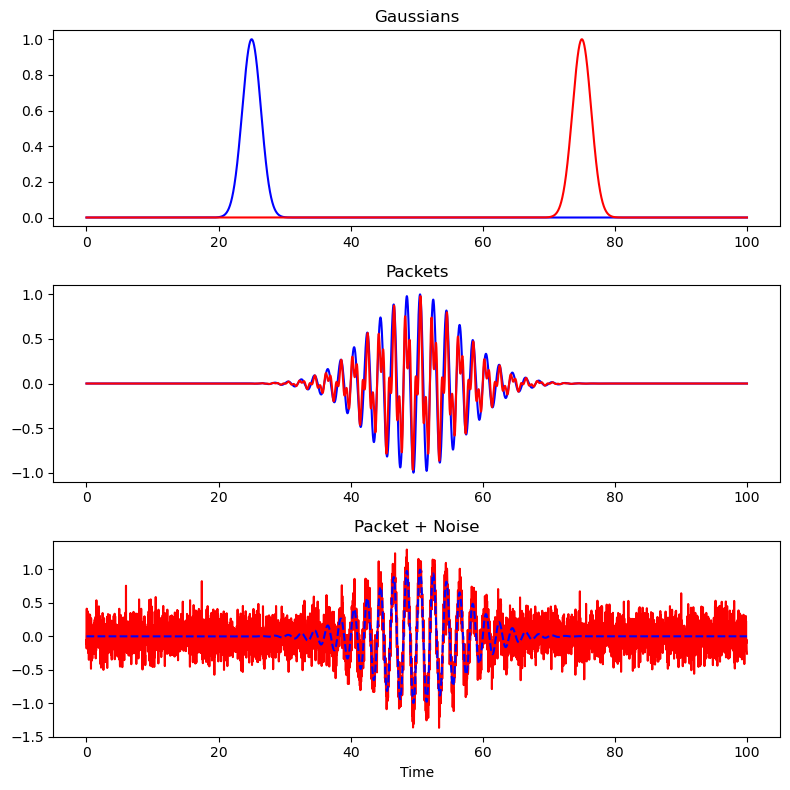

In [6]:
# -----------------------------
# Plot signals (Figure 11)
# -----------------------------
plt.figure(figsize=(8,8))

plt.subplot(3,1,1)
plt.plot(t, f1a, 'b')
plt.plot(t, f1b, 'r')
plt.title("Gaussians")

plt.subplot(3,1,2)
plt.plot(t, f2a, 'b')
plt.plot(t, f2b, 'r')
plt.title("Packets")

plt.subplot(3,1,3)
plt.plot(t, f3b, 'r')
plt.plot(t, f3a, 'b--')
plt.xlabel('Time')
plt.title("Packet + Noise")

plt.tight_layout()
plt.show()


In [7]:
def plot_cwt(signal, N, title, my_dt):
    Wx, scales = cwt(
        signal,
        wavelet='morlet',
        fs=1/my_dt,
        nv=48  # number of voices
    )
    
    freqs = scale_to_freq(scales, wavelet='morlet', fs=1/my_dt, N=N)

    plt.figure(figsize=(4, 3), layout='constrained')
    plt.pcolormesh(t, freqs, np.abs(Wx), shading='auto')
    plt.yscale('log')
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.colorbar(label='|CWT|')
    plt.show()
    return

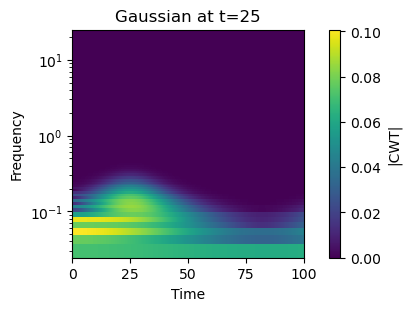

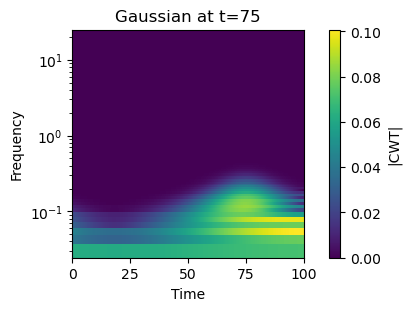

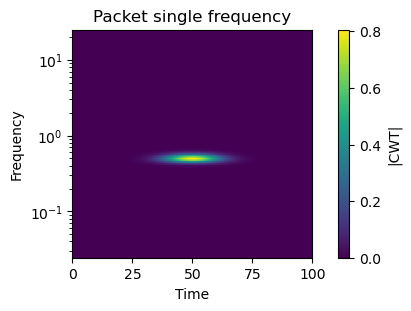

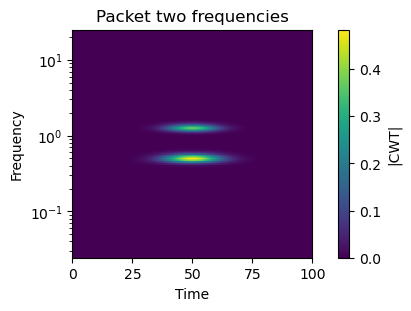

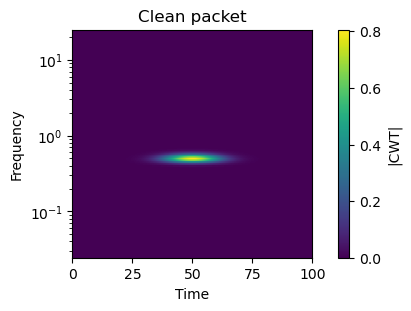

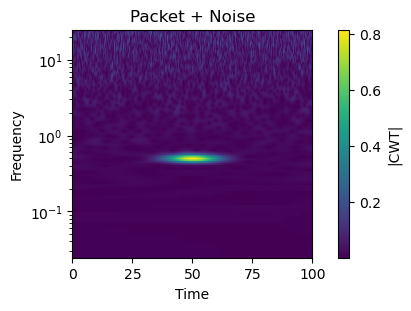

In [10]:
NN = 1000

plot_cwt(f1a, NN, "Gaussian at t=25", dt)
plot_cwt(f1b, NN, "Gaussian at t=75", dt)

plot_cwt(f2a, NN, "Packet single frequency", dt)
plot_cwt(f2b, NN, "Packet two frequencies", dt)

plot_cwt(f3a, NN, "Clean packet", dt)
plot_cwt(f3b, NN, "Packet + Noise", dt)

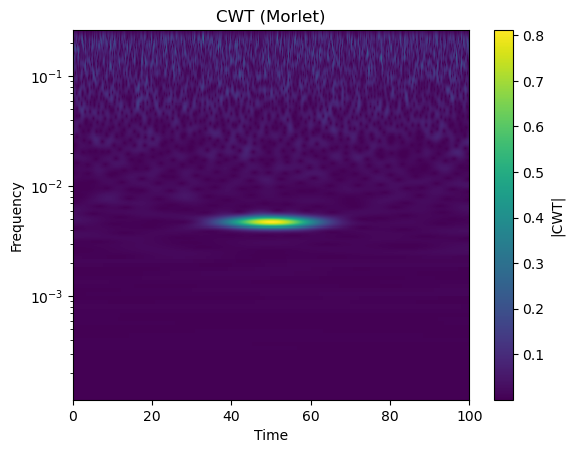

In [11]:
Wx, scales = cwt(f3b, wavelet='morlet', fs=1/dt)

# Convert scales to frequency
freqs = 1 / scales

plt.figure()
plt.pcolormesh(t, freqs, np.abs(Wx), shading='auto')
plt.yscale('log')
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.title("CWT (Morlet)")
plt.colorbar(label='|CWT|')
plt.show()

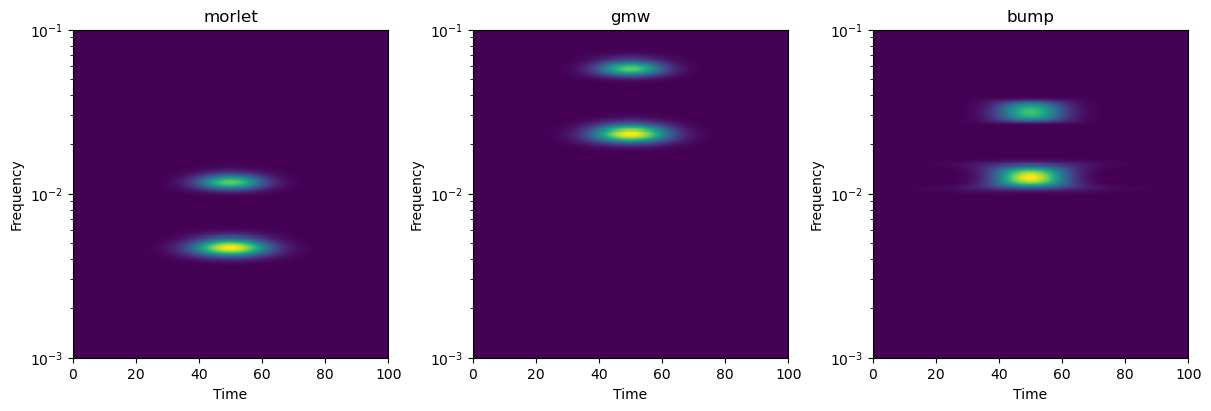

In [12]:
# morlet = gabor/amor wavelet in matlab
# gmw = generalized Morse wavelet
wavelets = ['morlet', 'gmw', 'bump']  
voices_per_octave = 48

fig, axs = plt.subplots(ncols=len(wavelets), figsize=(12,4), layout='constrained')

for i, wname in enumerate(wavelets):
    Wx, scales = cwt(f2b, wavelet=wname, fs=1/dt, nv=voices_per_octave)
    freqs = 1 / scales

    axs[i].pcolormesh(t, freqs, np.abs(Wx), shading='auto')
    axs[i].set_yscale('log')
    axs[i].set_ylim([1e-3, 1e-1])
    axs[i].set_xlabel("Time")
    axs[i].set_ylabel("Frequency")
    axs[i].set_title(wname)

plt.show()

The Morlet wavelet has the lowest frequency and the generalized Morse wavelet (GMW) has the highest frequency. The continuous wavelet transform maxima are of a similar shape between the Morlet and GMW wavelets, while the bump wavelet maxima are more boxy.

In [32]:
wavs()

{'bump', 'cmhat', 'gmw', 'hhhat', 'morlet'}

cmhat: Complex Mexican Hat wavelet.  
hhhat: Hilbert analytic function of Hermitian Hat.